In [3]:
! pip install scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 1.2 MB/s  0:00:10m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-image] [scikit-image]

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import os 
import matplotlib.pyplot as plt
from skimage.feature import hog
import random 
import cv2 


In [24]:
def get_hog_features(image):
    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=False,
        channel_axis=None,
    )
    return features


In [25]:
def load_and_extract_features(data_dir, target_size=(64, 64)):
    data = []
    labels = []
    for label in os.listdir(data_dir):
        label_dir = os.path.join(data_dir, label)
        if os.path.isdir(label_dir):
            for img_file in os.listdir(label_dir):
                img_path = os.path.join(label_dir, img_file)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    if target_size is not None:
                        img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
                    features = get_hog_features(img)
                    data.append(features)
                    labels.append(label)
    return np.array(data), np.array(labels)


In [26]:
def train_random_forest(X, y, n_estimators=200, random_state=42):
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=random_state,
        n_jobs=-1,
    )
    rf.fit(X, y)
    return rf


In [27]:
spiral_train_X,spiral_train_y=load_and_extract_features('/Users/imac/Downloads/spiral/training')
wave_train_X,wave_train_y=load_and_extract_features('/Users/imac/Downloads/wave/training')

In [28]:
spiral_rf_classifier = train_random_forest(spiral_train_X, spiral_train_y)
wave_rf_classifier = train_random_forest(wave_train_X, wave_train_y)


In [29]:
spiral_test_X,spiral_test_y =load_and_extract_features('/Users/imac/Downloads/spiral/testing')
wave_test_X,wave_test_y=load_and_extract_features('/Users/imac/Downloads/wave/testing')

In [30]:
spiral_predictions = spiral_rf_classifier.predict(spiral_test_X)
wave_predictions = wave_rf_classifier.predict(wave_test_X)


In [31]:
spiral_accuracy = accuracy_score(spiral_test_y, spiral_predictions)
wave_accuracy = accuracy_score(wave_test_y, wave_predictions)
print(f"Spiral Test Accuracy: {spiral_accuracy:.4f}")
print(f"Wave Test Accuracy: {wave_accuracy:.4f}")

Spiral Test Accuracy: 0.7667
Wave Test Accuracy: 0.8000


In [32]:
cm=confusion_matrix(spiral_test_y, spiral_predictions)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[12  3]
 [ 4 11]]


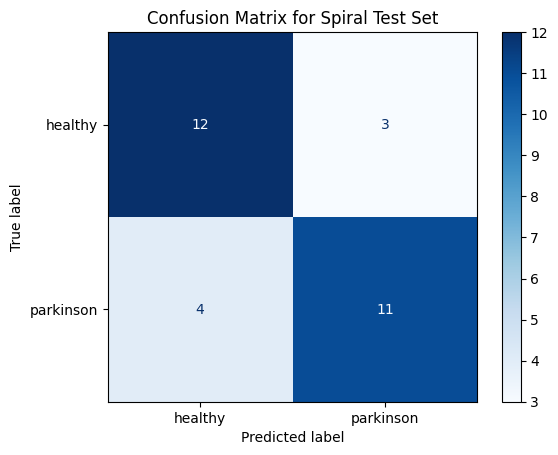

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=spiral_rf_classifier.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix for Spiral Test Set")
plt.show()
